# 02. Default & Prepayment Modeling - Freddie Mac SFLLD

## Summary

This notebook builds and evaluates predictive models for mortgage default,
defined as a loan ever reaching 90+ days delinquent, using Freddie Mac SFLLD
sample data (2018–2022 vintages, restricted to avoid right-censoring bias
from insufficient performance history in more recent years). Key findings:

- The base default rate is low (~3.5%), creating a meaningfully imbalanced
  classification problem where accuracy is not a useful evaluation metric.
- A Logistic Regression baseline required feature scaling to learn any signal
  at all — without it, the model degenerated to predicting the majority class
  for every loan.
- Random Forest achieved marginally better performance (ROC-AUC 0.769 vs.
  0.763), suggesting the current performance ceiling is driven more by limited
  feature scope and sample size than by model complexity.
- Feature importance analysis shows credit score, interest rate, and DTI
  account for over 74% of predictive signal, consistent with established
  mortgage risk knowledge.
- Threshold analysis illustrates the precision-recall trade-off inherent to
  rare-event prediction, with threshold choice ultimately depending on the
  business cost of missed defaults vs. false alarms.
- **Next steps:** test whether performance improves with the full (non-sample)
  dataset and additional categorical features (property state, occupancy
  status, loan purpose).

## 1. Inspect Raw Performance Data Structure

Before parsing the performance (servicing) files with pandas, inspect the raw
text to understand the delimiter, structure, and reporting frequency (the
`sample_svcg_YYYY` files contain monthly loan performance records, distinct
from the quarterly origination cohort implied by the loan sequence number,
e.g., "Q1" in `F18Q10000028`).

In [1]:
#Inspect the raw structure of the performance (servicing) file
with open('../data/raw/sample_2018/sample_svcg_2018.txt', 'r') as f:
    for i in range(5):
        print(f.readline())

F18Q10000028|201802|50000.00|0|000|360|||||4.500|0.00||||||||||||||75||||||50000.00

F18Q10000028|201803|50000.00|0|001|359|||||4.500|0.00||||||||||||||76||||||50000.00

F18Q10000028|201804|50000.00|0|002|358|||||4.500|0.00||||||||||||||73||||||50000.00

F18Q10000028|201805|50000.00|0|003|357|||||4.500|0.00||||||||||||||47||||||50000.00

F18Q10000028|201806|50000.00|0|004|356|||||4.500|0.00||||||||||||||47||||||50000.00



In [2]:
# Count the number of pipe-delimited fields in the first line

with open('../data/raw/sample_2018/sample_svcg_2018.txt', 'r') as f:
    first_line = f.readline()
    fields = first_line.strip().split('|')
    print(len(fields))
    print(fields)

32
['F18Q10000028', '201802', '50000.00', '0', '000', '360', '', '', '', '', '4.500', '0.00', '', '', '', '', '', '', '', '', '', '', '', '', '', '75', '', '', '', '', '', '50000.00']


## 2. Define Performance File Headers

The performance file has 32 pipe-delimited fields with no header. Assign
official Freddie Mac column names (pre-July-2026 schema, matching the loan
sequence number format observed in the origination data).

In [3]:
svcg_columns = [
    'loan_sequence_number',
    'monthly_reporting_period',
    'current_actual_upb',
    'current_loan_delinquency_status',
    'loan_age',
    'remaining_months_to_maturity',
    'defect_settlement_date',
    'modification_flag',
    'zero_balance_code',
    'zero_balance_effective_date',
    'current_interest_rate',
    'current_deferred_upb',
    'ddlpi',  # Due Date of Last Paid Installment
    'mi_recoveries',
    'net_sales_proceeds',
    'non_mi_recoveries',
    'expenses',
    'legal_costs',
    'maintenance_preservation_costs',
    'taxes_insurance',
    'miscellaneous_expenses',
    'actual_loss_calculation',
    'modification_cost',
    'step_modification_flag',
    'deferred_payment_plan',
    'estimated_ltv',
    'zero_balance_removal_upb',
    'delinquent_accrued_interest',
    'delinquency_due_to_disaster',
    'borrower_assistance_status_code',
    'current_month_modification_cost',
    'interest_bearing_upb'
]

## 3. Load Performance Data

Load monthly performance records for 2018 using the reusable `load_svcg_data()`
function (added to `src/data_loader.py`, following the same pattern as the
origination data loader).

In [4]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_loader import load_orig_data, clean_orig_data, load_svcg_data

df_svcg_2018 = load_svcg_data(2018)
df_svcg_2018.head()

,loan_sequence_number,monthly_reporting_period,current_actual_upb,current_loan_delinquency_status,loan_age,remaining_months_to_maturity,defect_settlement_date,modification_flag,zero_balance_code,zero_balance_effective_date,...,modification_cost,step_modification_flag,deferred_payment_plan,estimated_ltv,zero_balance_removal_upb,delinquent_accrued_interest,delinquency_due_to_disaster,borrower_assistance_status_code,current_month_modification_cost,interest_bearing_upb
0,F18Q10000028,201802,50000.0,0,0,360,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,75,NaN,NaN,NaN,NaN,NaN,50000.0
1,F18Q10000028,201803,50000.0,0,1,359,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,76,NaN,NaN,NaN,NaN,NaN,50000.0
2,F18Q10000028,201804,50000.0,0,2,358,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,73,NaN,NaN,NaN,NaN,NaN,50000.0
3,F18Q10000028,201805,50000.0,0,3,357,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,47,NaN,NaN,NaN,NaN,NaN,50000.0
4,F18Q10000028,201806,50000.0,0,4,356,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,47,NaN,NaN,NaN,NaN,NaN,50000.0


## 4. Define Default: Ever 90+ Days Delinquent

Before defining a default label, inspect the distribution of
`current_loan_delinquency_status` values. The standard mortgage risk
definition of default used here is "Ever 90+ Days Delinquent" (delinquency
status ≥ 3), meaning the loan reached at least 3 months delinquent at any
point in its observed performance history.

In [5]:
# Convert delinquency status to numeric; non-numeric codes (e.g., 'RA') become NaN
df_svcg_2018['delinquency_status_numeric'] = pd.to_numeric(
    df_svcg_2018['current_loan_delinquency_status'], errors='coerce'
)

# Properly sorted numeric counts
print(df_svcg_2018['delinquency_status_numeric'].value_counts().sort_index())

# Check what got excluded (non-numeric codes)
print(df_svcg_2018[df_svcg_2018['delinquency_status_numeric'].isna()]['current_loan_delinquency_status'].value_counts())

delinquency_status_numeric
0.0     1943094
1.0       21357
2.0        7146
3.0        4353
4.0        3236
         ...   
66.0          2
67.0          1
68.0          1
69.0          1
70.0          1
Name: count, Length: 71, dtype: int64
current_loan_delinquency_status
RA    182
Name: count, dtype: int64


## 5. Create Loan-Level Default Label

Aggregate monthly performance records to the loan level: for each loan,
determine whether it was ever 90+ days delinquent (delinquency status ≥ 3)
at any point in its observed history. This becomes the binary target variable
for default prediction.

In [6]:
# Re-confirm the column is numeric before grouping
max_delinquency_per_loan = df_svcg_2018.groupby('loan_sequence_number')['delinquency_status_numeric'].max()

print(max_delinquency_per_loan.dtype)  # should print float64

default_labels = (max_delinquency_per_loan >= 3).astype(int)
print(default_labels.value_counts())
print(f"Default rate: {default_labels.mean():.2%}")

float64
delinquency_status_numeric
0    47319
1     2681
Name: count, dtype: int64
Default rate: 5.36%


### Note: Class Imbalance

The default rate in the 2018 vintage is 5.36% (2,681 of 50,000 loans ever
reached 90+ days delinquent). This is a meaningfully imbalanced target. A
naive model predicting "no default" for every loan would already achieve
94.6% accuracy. This means accuracy alone will not be a meaningful evaluation
metric later; precision, recall, and ROC-AUC will be more informative when
building predictive models.

## 6. Merge Origination Features with Default Label (2018)

Combine origination loan characteristics (credit score, LTV, DTI, etc.) with
the loan-level default label derived from performance data, joining on
`loan_sequence_number`. Validate this merge logic on a single vintage year
before scaling to the full 2018–2025 dataset.

In [7]:
# Load and clean 2018 origination data
df_orig_2018 = load_orig_data(2018)
df_orig_2018 = clean_orig_data(df_orig_2018)

# Convert default_labels (a Series indexed by loan_sequence_number) into a DataFrame for merging
default_labels_df = default_labels.reset_index()
default_labels_df.columns = ['loan_sequence_number', 'default_flag']

# Merge on loan_sequence_number
df_model_2018 = df_orig_2018.merge(default_labels_df, on='loan_sequence_number', how='left')

print(df_orig_2018.shape)
print(default_labels_df.shape)
print(df_model_2018.shape)
print(df_model_2018['default_flag'].isna().sum())

(50000, 33)
(50000, 2)
(50000, 34)
0


### Merge Validation

The merge on `loan_sequence_number` preserved the original row count (50,000)
with zero unmatched loans, confirming that every origination record has a
corresponding default label from the performance data. This validates the
merge logic before scaling to all vintage years.

In [8]:
from data_loader import build_model_dataset

years = range(2018,2026)

model_df_list = []
for year in years:
    df_year = build_model_dataset(year)
    model_df_list.append(df_year)

df_all_model = pd.concat(model_df_list,ignore_index=True)

print(df_all_model.shape)

# Check default rate by vintage year. Watch for right-censoring in recent years
print(df_all_model.groupby('vintage_year')['default_flag'].mean())

(387500, 35)
vintage_year
2018    0.05362
2019    0.05482
2020    0.02076
2021    0.01804
2022    0.03020
2023    0.01848
2024    0.00630
2025    0.00040
Name: default_flag, dtype: float64


### Note: Right-Censoring in Recent Vintage Years

Default rates decline sharply for 2020 onward, reaching an implausibly low
0.04% for 2025. This is not likely to reflect genuinely safer loans. It
reflects **right-censoring**: loans originated more recently have had less
time to reach 90+ days delinquent, since mortgage defaults typically peak
2-3 years after origination.

**Decision:** Restrict the modeling dataset to vintage years with at least
~3 years of observed performance history (2018–2022) to ensure the default
label reflects a fair measurement window. 2023–2025 vintages will be excluded
from model training (though they could later be used as an out-of-time
validation set once more performance history accumulates).

In [9]:
# Restrict to vintage years with sufficient performance history to avoid right-censoring bias
df_model = df_all_model[df_all_model['vintage_year'] <= 2022].copy()

print(df_model.shape)
print(df_model.groupby('vintage_year')['default_flag'].mean())

(250000, 35)
vintage_year
2018    0.05362
2019    0.05482
2020    0.02076
2021    0.01804
2022    0.03020
Name: default_flag, dtype: float64


## 7. Baseline Model: Logistic Regression

Build a baseline logistic regression model to predict `default_flag` using
loan-level origination features. This establishes a simple, interpretable
benchmark before trying more complex models (e.g., random forest, XGBoost).

In [10]:
features = [
    'credit_score', 'original_cltv', 'original_dti', 'original_upb',
    'original_ltv', 'original_interest_rate', 'original_loan_term',
    'number_of_borrowers', 'number_of_units'
]

target = 'default_flag'

# Drop rows with missing values in selected features (simplest approach for a baseline)
df_baseline = df_model[features + [target]].dropna()

print(df_baseline.shape)
print(df_baseline[target].value_counts(normalize=True))

(249392, 10)
default_flag
0    0.964698
1    0.035302
Name: proportion, dtype: float64


## 8. Train/Test Split

Split the dataset into training and test sets to evaluate the model on data
it has not seen during training, which is necessary to assess how well it
generalizes rather than simply memorizing the training data.

In [11]:
from sklearn.model_selection import train_test_split

X = df_baseline[features]
y = df_baseline[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(199513, 9) (49879, 9)
0.035300957832321705 0.03530543916277391


In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


## 9. Evaluate Baseline Model

Evaluate the trained logistic regression model on the held-out test set.
Since the target is imbalanced (~3.5% default rate), accuracy alone is not
a meaningful metric — precision, recall, and ROC-AUC will be more informative.

In [13]:
from sklearn.metrics import classification_report, roc_auc_score

# Predicted class (0 or 1) and predicted probability of default
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     48118
           1       0.00      0.00      0.00      1761

    accuracy                           0.96     49879
   macro avg       0.48      0.50      0.49     49879
weighted avg       0.93      0.96      0.95     49879

ROC-AUC: 0.5000


C:\Users\euihy\PycharmProjects\Mortgage_Prepayment_Analytics\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\euihy\PycharmProjects\Mortgage_Prepayment_Analytics\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\euihy\PycharmProjects\Mortgage_Prepayment_Analytics\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

### First Attempt: Unscaled Features

```
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     48118
           1       0.00      0.00      0.00      1761

    accuracy                           0.96     49879
   macro avg       0.48      0.50      0.49     49879
weighted avg       0.93      0.96      0.95     49879

ROC-AUC: 0.5000
```

**Diagnosis:** The model failed to learn any signal (ROC-AUC = 0.5, equivalent
to random guessing) and predicted "no default" for every loan. This is likely
because Logistic Regression is sensitive to feature scale, and features here
range from small (interest rate: ~3-7) to very large (UPB: tens of thousands) —
without scaling, larger-magnitude features can dominate the optimization.

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred, zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     48118
           1       0.00      0.00      0.00      1761

    accuracy                           0.96     49879
   macro avg       0.48      0.50      0.49     49879
weighted avg       0.93      0.96      0.95     49879

ROC-AUC: 0.7627


### Note: Threshold Issue

Although ROC-AUC improved to 0.76 (indicating the model learned a meaningful
signal), precision/recall for the default class remain 0 at the default 0.5
probability threshold. This is expected with a ~3.5% base default rate — the
model rarely assigns >50% probability to any single loan. The next step is to
lower the classification threshold to make the model more sensitive to
predicting default.

## 10. Adjust Classification Threshold

Lower the probability threshold for classifying a loan as "default" (from the
default 0.5) to make the model more sensitive to the minority class, given the
low base default rate (~3.5%).

In [15]:
# Trying a lower threshold to increase sensitivity to the minority (default) class
threshold = 0.15

y_pred_adjusted = (y_pred_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred_adjusted, zero_division=0))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     48118
           1       0.18      0.09      0.12      1761

    accuracy                           0.95     49879
   macro avg       0.58      0.54      0.55     49879
weighted avg       0.94      0.95      0.95     49879



In [16]:
for threshold in [0.05, 0.10, 0.15, 0.20, 0.25]:
    y_pred_adjusted = (y_pred_proba >= threshold).astype(int)
    report = classification_report(y_test, y_pred_adjusted, output_dict=True, zero_division=0)
    print(f"Threshold: {threshold}")
    print(f"  Class 1 - Precision: {report['1']['precision']:.3f}, Recall: {report['1']['recall']:.3f}, F1: {report['1']['f1-score']:.3f}")

Threshold: 0.05
  Class 1 - Precision: 0.090, Recall: 0.583, F1: 0.157
Threshold: 0.1
  Class 1 - Precision: 0.140, Recall: 0.245, F1: 0.178
Threshold: 0.15
  Class 1 - Precision: 0.183, Recall: 0.090, F1: 0.120
Threshold: 0.2
  Class 1 - Precision: 0.215, Recall: 0.026, F1: 0.047
Threshold: 0.25
  Class 1 - Precision: 0.310, Recall: 0.007, F1: 0.014


### Threshold Trade-off Analysis

Testing thresholds from 0.05 to 0.25 reveals a clear precision-recall trade-off:
lower thresholds catch more true defaults (recall) at the cost of more false
positives (lower precision), and vice versa. F1-score peaks around threshold
0.10 (F1 = 0.178), balancing both metrics.

In a mortgage risk context, missing a true default is typically more costly
than a false alarm (which just triggers additional review), so a lower
threshold favoring recall (e.g., 0.05–0.10) may be more appropriate in
practice — though the "right" threshold ultimately depends on the specific
business cost of false positives vs. false negatives, which is a business
decision rather than a purely statistical one.

## 11. Random Forest Model

Train a Random Forest classifier on the same features and compare its
performance (ROC-AUC, precision/recall) against the Logistic Regression
baseline. Random Forest can capture non-linear relationships and feature
interactions that Logistic Regression cannot.

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest does not require feature scaling
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print(f"Random Forest ROC-AUC: {roc_auc_score(y_test, rf_pred_proba):.4f}")
print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

Random Forest ROC-AUC: 0.7686
Logistic Regression ROC-AUC: 0.7627


### Comparison: Random Forest vs. Logistic Regression

Random Forest achieved a marginally higher ROC-AUC (0.7686) than Logistic
Regression (0.7627) — a negligible improvement despite Random Forest's ability
to capture non-linear feature interactions. This suggests the performance
ceiling here is more likely driven by limited feature information (only
origination-time loan characteristics) and/or limited sample size, rather
than model complexity. Adding a more powerful algorithm does not meaningfully
help when the underlying features don't carry much additional predictive signal.

credit_score              0.430651
original_interest_rate    0.185993
original_dti              0.129044
number_of_borrowers       0.063713
original_upb              0.063357
original_cltv             0.063202
original_ltv              0.046190
original_loan_term        0.013621
number_of_units           0.004229
dtype: float64


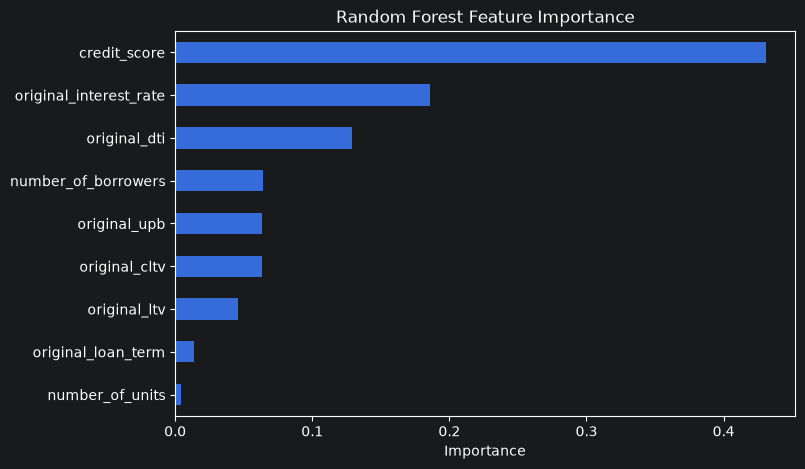

In [18]:
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.show()

### Feature Importance (Random Forest)

Credit score is by far the most important predictor (43.1%), followed by
original interest rate (18.6%) and DTI (12.9%) — together these three
features account for over 74% of total feature importance. This aligns with
common industry knowledge that credit score is one of the strongest single
predictors of mortgage default risk. Interest rate's high importance likely
reflects that it already encodes lender risk-based pricing at origination
(riskier borrowers receive higher rates), meaning it partially captures
information similar to credit score and DTI. Remaining features (loan term,
number of units, etc.) contribute comparatively little, which may help explain
why more complex models (Random Forest) didn't meaningfully outperform the
simpler Logistic Regression baseline — most of the predictive signal is
concentrated in a small number of variables.

### Note: Feature Selection Scope

This baseline model uses only 9 numeric features that required no additional
preprocessing. Several categorical variables were excluded for simplicity but
are plausible candidates for improving the model in future iterations —
particularly `property_state` (geographic risk variation), `occupancy_status`
(investment properties tend to carry higher default risk), and `loan_purpose`
(purchase vs. refinance). These would require encoding (e.g., one-hot encoding)
before being usable in these models. Identifier fields (loan sequence number,
seller/servicer name) and fields with substantial missingness (MSA, HARP-related
flags) were excluded outright.